git add micrograd-master/
git commit -m "更新说明"
git push origin main

In [26]:
class Car: 
    """一次模拟汽车的简单尝试""" 
 
    def __init__(self, make, model, year): 
        """初始化描述汽车的属性""" 
        self.make = make 
        self.model = model 
        self.year = year 
         
    def get_descriptive_name(self): 
        """返回整洁的描述性信息""" 
        long_name = str(self.year) + ' ' + self.make + ' ' + self.model 
        return long_name.title()

my_new_car = Car('audi', 'a4', 2016) 
print(my_new_car)
my_new_car


In [51]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

class Value:

    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):  #
        return f"Value(data={self.data})"
    

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self,other),'+') ## 创建并返回一个新的 Value 对象，其 data 为两者相加之和

        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward   

        return out

    def __radd__(self,other): # other + self
        return self + other
    
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),'*')
    
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __rmul__(self,other):
        return self*other

    def __truediv__(self,other):# self / other
        return self * other**-1

    def __neg__(self): #-self
        return self*-1

    def __sub__(self,other): #self-other
        return self + (-other)

    def __pow__(self, other):
        # 确保 other 是 int 或 float 类型（次方通常是常数，如 -1, 2, 0.5 等）
        assert isinstance(other, (int, float)), "目前只支持 int/float 作为指数"
        # 计算次方后的新值
        out = Value(self.data ** other, (self,), f'**{other}')
        # 补全反向传播梯度计算逻辑（用于 autograd）
        def _backward():
            # d(x^n)/dx = n * x^(n-1) * dL/dout
            self.grad += (other * (self.data ** (other - 1))) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t =(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad += (1-t**2)*out.grad
        out._backward = _backward


        return out

    def exp(self):
        x=self.data
        out = Value(math.exp(x),(self,),'exp')

        def _backward():
            self.grad += out.data*out.grad
        out._backward = _backward

        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()




    
    

a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c')
#a+b 相当于a.__add__(b)
e=a*b; e.label='e' #相当于a.__mul__(b)
d = e +c; d.label='d' #相当于(a.__mul__(b)).__add__(c)
f=Value(-2.0,label='f')
L = d*f;L.label='L'
L


Value(data=-8.0)

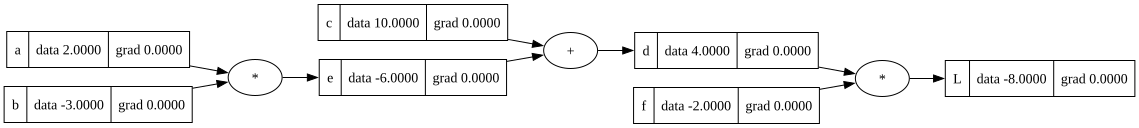

In [97]:
draw_dot(L)

In [98]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [99]:
d._op


'+'

![image-4.png](./images/img_10.png)
![image-9.png](./images/img_15.png)
![image.png](./images/img_16.png)
![image-2.png](./images/img_8.png)
![image-3.png](./images/img_9.png)

这里a+b报错是因为 Python 不知道两个自定义对象相加 (+) 到底该怎么算。在 Python 里，如果你想让自定义的类（Value）支持加法符号 +，你必须在类里面实现魔法方法 __add__。

![image-5.png](./images/img_11.png)
![image-6.png](./images/img_12.png)
![image-7.png](./images/img_13.png)
![image-8.png](./images/img_14.png)
![image-10.png](./images/img_1.png)
![image-11.png](./images/img_2.png)
![image-12.png](./images/img_3.png)
![image-13.png](./images/img_4.png)
![image-14.png](./images/img_5.png)
![image-15.png](./images/img_6.png)
![image-16.png](./images/img_7.png)

![image.png](./images/img_24.png)
![image-2.png](./images/img_17.png)
![image-3.png](./images/img_18.png)
![image-4.png](./images/img_19.png)
![image-5.png](./images/img_20.png)
![image-6.png](./images/img_21.png)
![image-7.png](./images/img_22.png)
![image-8.png](./images/img_23.png)

In [100]:
f.grad = 4.0
d.grad = -2.0

![image.png](./images/img_27.png)
![image-2.png](./images/img_25.png)
![image-3.png](./images/img_26.png)


In [101]:
def lol():
    h = 1e-4

    a = Value(2.0,label = 'a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b; e.label='e' 
    d = e +c ; d.label='d'
    f=Value(-2.0,label='f')
    L = d*f;L.label='L'
    L1=L.data

    a = Value(2.0,label = 'a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b; e.label='e' 
    d = e +c ; d.label='d'
    f=Value(-2.0,label='f')
    L = d*f;L.label='L'
    L2=L.data+h
    #print((L.data+h-L.data)/h)

    print((L2-L1)/h)

lol()






0.9999999999976694


![image.png](./images/img_28.png)

![image.png](./images/img_32.png)
![image-2.png](./images/img_29.png)
![image-3.png](./images/img_30.png)
![image-4.png](./images/img_31.png)



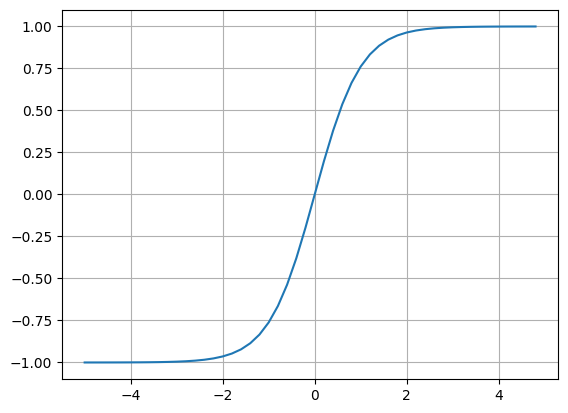

In [102]:
import matplotlib.pyplot as plt
import numpy as np  
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))
plt.grid()


![image.png](./images/img_35.png)
![image-2.png](./images/img_33.png)
![image-3.png](./images/img_34.png)



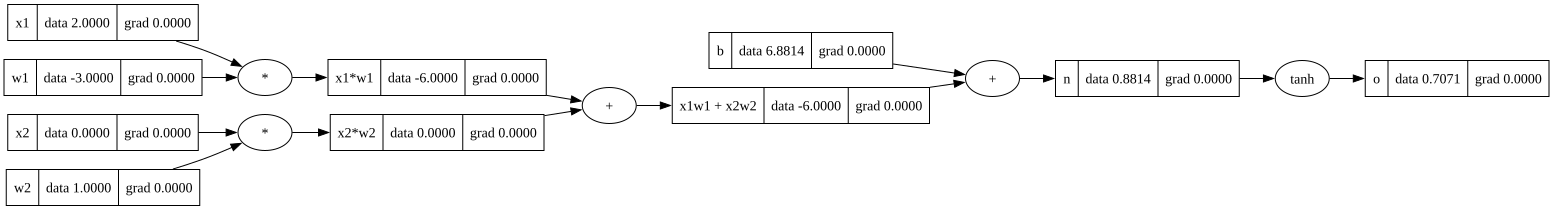

In [103]:
#inputs x1,x2
x1 = Value(2.0,label = 'x1')
x2 = Value(0.0,label = 'x2')
#weights w1,w2
w1 = Value(-3.0,label = 'w1')
w2 = Value(1.0,label = 'w2')
#bias of the neuron
b = Value(6.881373587019543,label = 'b')
# x1*w1 +x2*w2 + b 
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2;x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b;n.label = 'n'
o = n.tanh();o.label= 'o'   

#o.grad = 1.0  
#n.grad = 0.5  o=tanh(n)  do/dn = 1- o**2
#w1x1w2x2.grad = 0.5
#b.grad = 0.5
#w1x1.grad = 0.5
#w2x2.grad = 0.5
#w1.grad = w1x1.grad*x1.data=1.0    x1.grad = w1x1.grad*w1.data=-1.5
#w2.grad = w2x2.grad*x2.data=0    x2.grad = w2x2.grad*w2.data=0.5

draw_dot(o)



![image.png](./images/img_40.png)
![image-2.png](./images/img_36.png)
![image-4.png](./images/img_38.png)
![image-5.png](./images/img_39.png)
![image-3.png](./images/img_37.png)

In [104]:
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
x1.grad, x2.grad, w1.grad, w2.grad, b.grad


(-1.4999999999999996,
 0.4999999999999999,
 0.9999999999999998,
 0.0,
 0.4999999999999999)

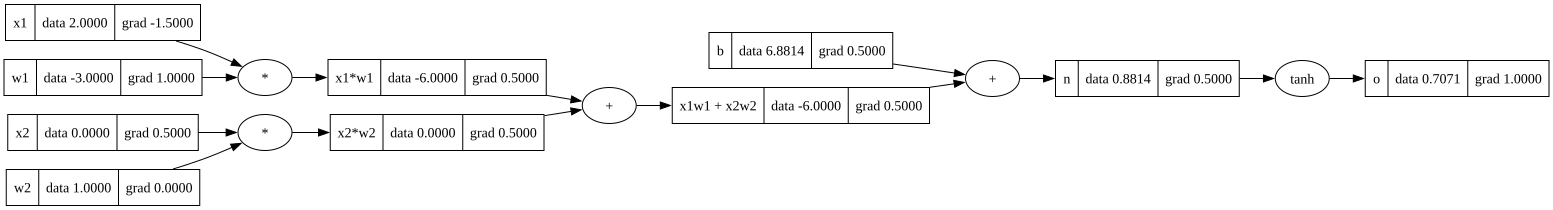

In [105]:
draw_dot(o)

In [106]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)  
build_topo(o)   
topo    
    

[Value(data=6.881373587019543),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

![image.png](./images/img_48.png)
![image-2.png](./images/img_41.png)
![image-3.png](./images/img_42.png)
![image-4.png](./images/img_43.png)
![image-5.png](./images/img_44.png)
![image-6.png](./images/img_45.png)
![image-7.png](./images/img_46.png)
![image-8.png](./images/img_47.png)



In [107]:
o.backward()

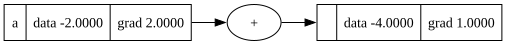

In [108]:
a = Value(-2.0,label = 'a')
b = a+a;label = 'b'
b.backward()
draw_dot(b)

![image.png](./images/img_59.png)
![image-2.png](./images/img_51.png)
![image-3.png](./images/img_52.png)
![image-4.png](./images/img_53.png)
![image-5.png](./images/img_54.png)
![image-6.png](./images/img_55.png)
![image-7.png](./images/img_56.png)
![image-8.png](./images/img_57.png)
![image-9.png](./images/img_58.png)
![image-10.png](./images/img_49.png)
![image-11.png](./images/img_50.png)



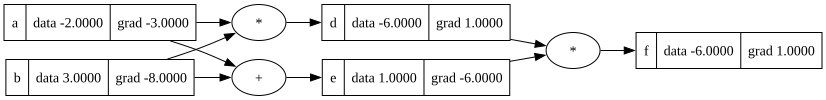

In [109]:
a = Value(-2.0,label="a")
b = Value(3.0,label='b')
d = a*b  ;d.label = 'd'
e = a+b  ;e.label = 'e'
f = d*e ;f.label = 'f'

f.backward()
draw_dot(f)


![image-2.png](./images/img_60.png)
![image.png](./images/img_65.png)
![image-3.png](./images/img_61.png)
![image-4.png](./images/img_62.png)
![image-5.png](./images/img_63.png)
![image-6.png](./images/img_64.png)

In [110]:
a = Value(2.0)
a+1

AttributeError: 'int' object has no attribute 'data'

AttributeError: 'int' object has no attribute 'data'
![image.png](./images/img_70.png)
other = other if isinstance(other, Value) else Value(other)
![image-2.png](./images/img_66.png)
![image-3.png](./images/img_67.png)
![image-4.png](./images/img_68.png)
![image-5.png](./images/img_69.png)

In [113]:
1+a

TypeError: unsupported operand type(s) for +: 'int' and 'Value'

TypeError: unsupported operand type(s) for +: 'int' and 'Value'
![image.png](./images/img_74.png)
![image-2.png](./images/img_71.png)
![image-3.png](./images/img_72.png)
![image-4.png](./images/img_73.png)

In [122]:
print(1+a)
print(2*a)

Value(data=3.0)
Value(data=4.0)


![image.png](./images/img_76.png)
![image-2.png](./images/img_75.png)  


In [127]:
a/Value(1.0)

TypeError: unsupported operand type(s) for ** or pow(): 'Value' and 'int'

![image.png](./images/img_78.png)
![image-2.png](./images/img_77.png)


In [130]:
b=Value(2.0)
a**b

AssertionError: 目前只支持 int/float 作为指数

![image-6.png](./images/img_83.png)
![image.png](./images/img_84.png)
![image-2.png](./images/img_79.png)
![image-3.png](./images/img_80.png)
![image-4.png](./images/img_81.png)
![image-5.png](./images/img_82.png)


  def __neg__(self): #-self
        return self*-1

    def __sub__(self,other): #self-other
        return self + (-other)
![image.png](./images/img_87.png)
![image-2.png](./images/img_85.png)
![image-3.png](./images/img_86.png)